In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
import os
import matsim
import numpy as np
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from scipy.spatial.distance import cdist
from shapely.geometry import Point, box

# Read Leuven network

<Axes: >

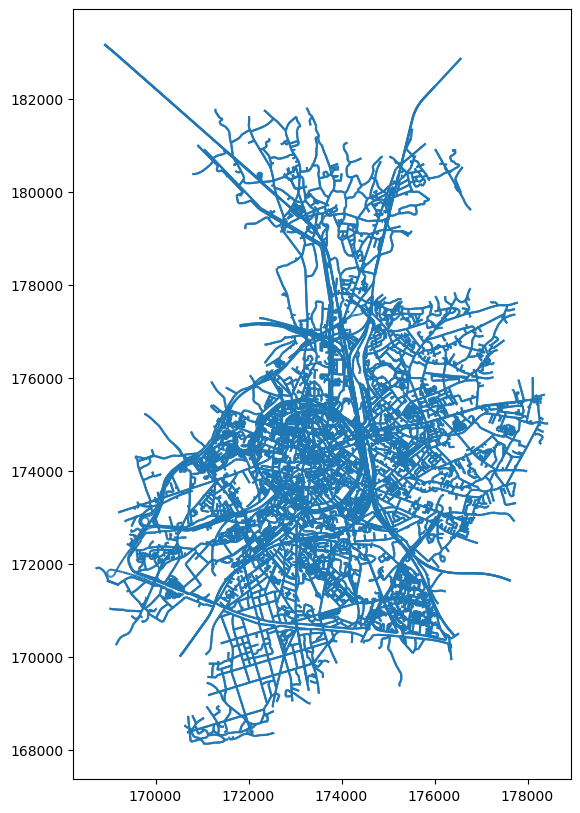

In [3]:
network_path = r'data/GemeenteLeuvenWithHbefaType/GemeenteLeuvenWithHbefaType.xml.gz'
network = matsim.read_network(network_path)
# convert to geopandas GeoDataFrame
network_gdf = network.as_geo()
network_gdf.plot(figsize=(10, 10))

<Axes: >

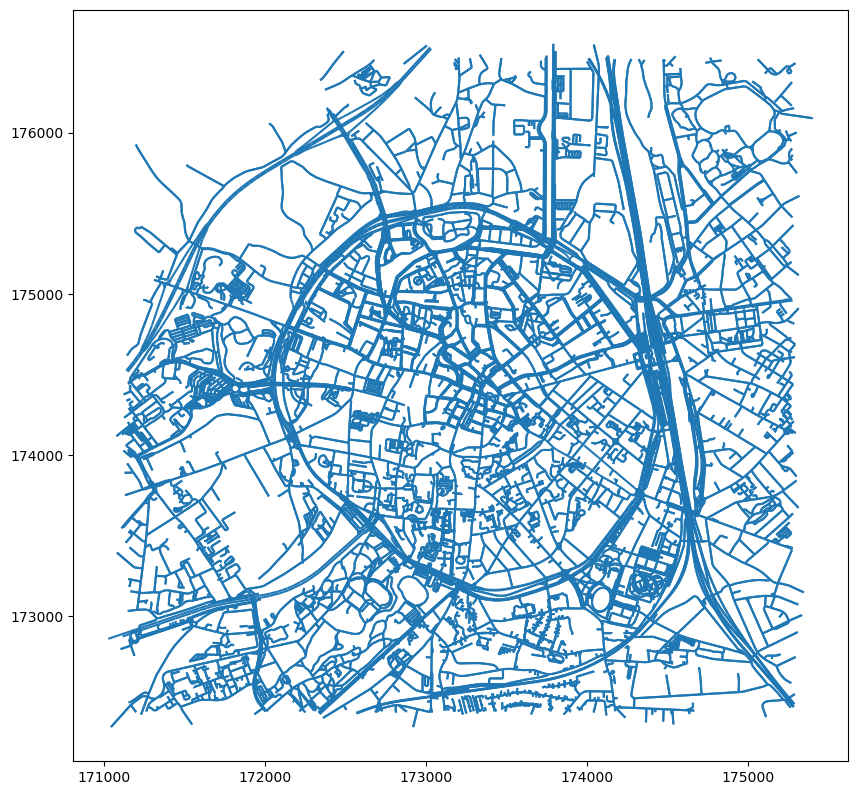

In [4]:
# Crop the network to the area of interest (Xmin:172161.734, Xmax:174265.856, Ymin:173412.828, Ymax:175444.093)
bbox4vis = (171161.734, 175265.856, 172412.828, 176444.093)
network_gdf_cropped = network_gdf.cx[bbox4vis[0]:bbox4vis[1], bbox4vis[2]:bbox4vis[3]]
network_gdf_cropped.plot(figsize=(10, 10))

<Axes: >

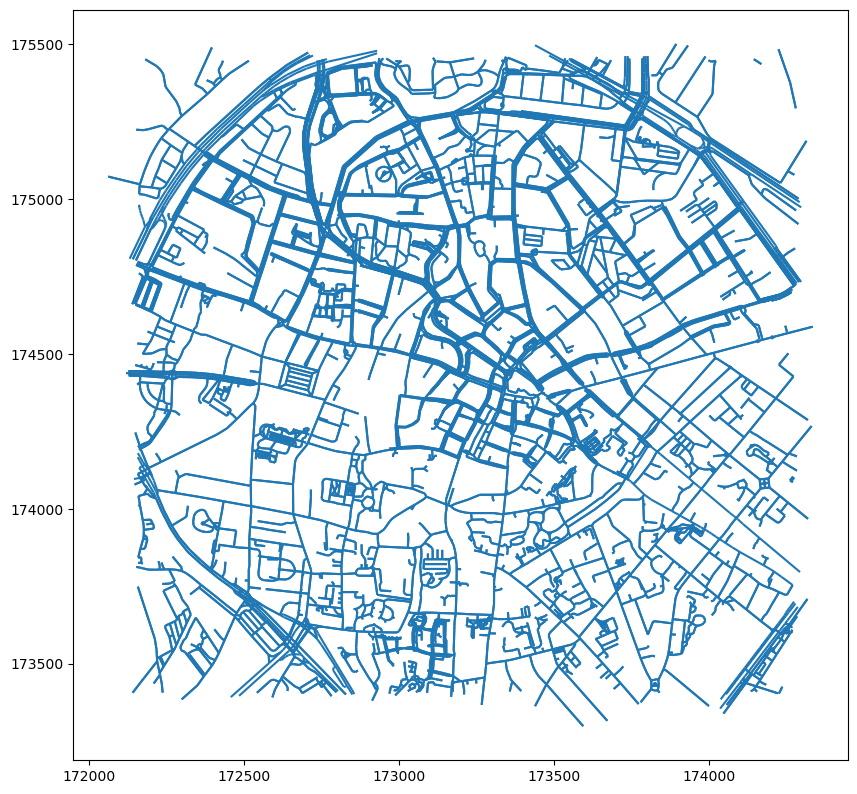

In [5]:
# Crop the network to the area of interest (Xmin:172161.734, Xmax:174265.856, Ymin:173412.828, Ymax:175444.093)
bbox = (172161.734, 174265.856, 173412.828, 175444.093)
network_gdf_cropped4customer = network_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
network_gdf_cropped4customer.plot(figsize=(10, 10))

# Path

In [6]:
data_dir = r'data/leuven_poi/data/'
os.listdir(data_dir)

['order_boundary.gpkg',
 'poi-fsq-point.gpkg',
 'poi-osm-point.gpkg',
 'poi-osm-polygon.gpkg',
 'poi-overture-point.gpkg']

In [7]:
fsq_poi_data_path = os.path.join(data_dir, 'poi-fsq-point.gpkg')
fsq_poi_gdf = gpd.read_file(fsq_poi_data_path)
fsq_poi_gdf

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
0,54f08a04498e311c6623740f,Het Bos,50.937848,4.733698,None,None,None,None,None,None,...,None,None,None,Landmarks and Outdoors,Tree,None,None,None,None,POINT (4.73370 50.93785)
1,4fd1bd87e4b03e7cedf5302c,Alteco,50.935559,4.726363,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Factory,None,None,None,None,POINT (4.72636 50.93556)
2,1dc816dd49ad4ab93d65637b,Dh Consult,50.935206,4.727068,Jef Scherensstraat 1,Wilsele,Vlaams-Brabant,3012,None,None,...,None,None,None,Business and Professional Services,Repair Service,None,None,None,None,POINT (4.72707 50.93521)
3,52c99d0e11d2356fb2817919,Legends Retro Café,50.936746,4.731189,Aarschotsesteenweg 749,Wilsele,Vlaams brabant,3012,None,None,...,None,None,None,Dining and Drinking,Bar,None,None,None,None,POINT (4.73119 50.93675)
4,57418dbb498e8a0626d2a2fd,Locked Escape Room Leuven,50.936682,4.731218,Aarschotsesteenweg 749,Wilsele,None,None,None,None,...,None,None,None,Arts and Entertainment,Escape Room,None,None,None,None,POINT (4.73122 50.93668)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23576,20fb60f468df44fd37157340,Krima,50.904575,4.721743,Wilselsesteenweg 257,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (4.72174 50.90458)
23577,3d940afa0dda420f017635a0,Bob de veiligheidscoördinator,50.905838,4.745195,Holsbeeksesteenweg 385,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (4.74519 50.90584)
23578,58822c09ca10705c93bb8ede,Rozenpad,50.888630,4.767532,Rozenpad,Leuven,None,3010,None,None,...,None,None,None,Landmarks and Outdoors,Forest,None,None,None,None,POINT (4.76753 50.88863)
23579,4cc44ce282388cfae6ed6d35,Zidazo,50.885448,4.768265,Lange Lostraat 46,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,Business and Professional Services,Office,None,None,None,None,POINT (4.76827 50.88545)


In [8]:
# Conver the crs to Leuven network crs (EPSG:31370)
fsq_poi_gdf = fsq_poi_gdf.to_crs(epsg=31370)
fsq_poi_gdf

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
0,54f08a04498e311c6623740f,Het Bos,50.937848,4.733698,None,None,None,None,None,None,...,None,None,None,Landmarks and Outdoors,Tree,None,None,None,None,POINT (175741.695 180842.237)
1,4fd1bd87e4b03e7cedf5302c,Alteco,50.935559,4.726363,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Factory,None,None,None,None,POINT (175227.310 180585.077)
2,1dc816dd49ad4ab93d65637b,Dh Consult,50.935206,4.727068,Jef Scherensstraat 1,Wilsele,Vlaams-Brabant,3012,None,None,...,None,None,None,Business and Professional Services,Repair Service,None,None,None,None,POINT (175277.058 180546.047)
3,52c99d0e11d2356fb2817919,Legends Retro Café,50.936746,4.731189,Aarschotsesteenweg 749,Wilsele,Vlaams brabant,3012,None,None,...,None,None,None,Dining and Drinking,Bar,None,None,None,None,POINT (175565.885 180718.734)
4,57418dbb498e8a0626d2a2fd,Locked Escape Room Leuven,50.936682,4.731218,Aarschotsesteenweg 749,Wilsele,None,None,None,None,...,None,None,None,Arts and Entertainment,Escape Room,None,None,None,None,POINT (175567.996 180711.705)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23576,20fb60f468df44fd37157340,Krima,50.904575,4.721743,Wilselsesteenweg 257,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174918.993 177136.702)
23577,3d940afa0dda420f017635a0,Bob de veiligheidscoördinator,50.905838,4.745195,Holsbeeksesteenweg 385,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (176567.917 177285.334)
23578,58822c09ca10705c93bb8ede,Rozenpad,50.888630,4.767532,Rozenpad,Leuven,None,3010,None,None,...,None,None,None,Landmarks and Outdoors,Forest,None,None,None,None,POINT (178149.395 175379.278)
23579,4cc44ce282388cfae6ed6d35,Zidazo,50.885448,4.768265,Lange Lostraat 46,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,Business and Professional Services,Office,None,None,None,None,POINT (178202.883 175025.579)


In [9]:
# Filter out POIs that are within the cropped network area
fsq_poi_gdf_cropped = fsq_poi_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
fsq_poi_gdf_cropped

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
1112,518749b0498ecce31857057e,Brug over R23,50.888903,4.692063,Nieuwe Mechelsesteenweg,Leuven,Vlaams-Brabant,None,None,None,...,None,None,None,Landmarks and Outdoors,Bridge,None,None,None,None,POINT (172838.911 175383.772)
1113,518749b0498ecce31857057e,Brug over R23,50.888903,4.692063,Nieuwe Mechelsesteenweg,Leuven,Vlaams-Brabant,None,None,None,...,None,None,None,Travel and Transportation,Road,None,None,None,None,POINT (172838.911 175383.772)
1114,5603cfb7498ed38532b5fd4b,royal kapsalon,50.889345,4.693120,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Health and Beauty Service,Hair Salon,None,None,None,POINT (172913.075 175433.254)
1115,6798e102ccd9c66bf0bb631a,Bus 11 Binnenring Bus,50.888847,4.692713,None,None,None,None,None,None,...,4bf58dd8d48988d12b951735,None,None,Travel and Transportation,Transportation Service,Public Transportation,Bus Line,None,None,POINT (172884.673 175377.706)
1116,55741fc9498e3c32c3a5b436,thé dansant bus 2 Highlands! 😎,50.888695,4.692087,None,None,None,None,None,None,...,None,None,None,Travel and Transportation,Transport Hub,Bus Stop,None,None,None,POINT (172840.695 175360.578)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23435,5349275a498eeee574439816,Two Tigers Store,50.874866,4.710616,Tiensestraat 176,Leuven,None,3000,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174151.580 173828.076)
23436,537e6c6f498e352d65d40932,batsbakdak,50.874521,4.710935,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174174.211 173789.801)
23437,5320d070498ebe7a6cbb6eac,soa's kot,50.875319,4.710648,burgemeestersstraat 14,leuven,None,3000,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174153.614 173878.428)
23438,7ef1c3dc4b044a3bede23fc3,Domatica Webhosting Design & Domainnames,50.875614,4.711258,Blijde Inkomststraat 26,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174196.382 173911.495)


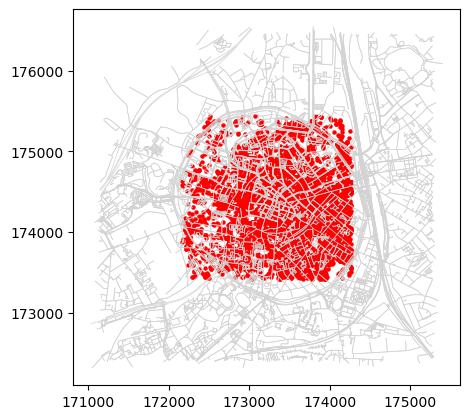

In [18]:
# visualize the cropped network and POIs
fig, ax = plt.subplots(figsize=(5, 5))
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped.plot(ax=ax, color='red', markersize=5)
plt.show()

## filter out the irrelevant POIs
- Since we aim to generate customers/receivers in the context of Urban freight system, we need to filter out those irrelevant POIs (e.g., tree, park, etc)

### Get the categories of the POIs

In [27]:
fsq_poi_gdf_cropped.query("cat1_name == 'Business and Professional Services'")

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
1114,5603cfb7498ed38532b5fd4b,royal kapsalon,50.889345,4.693120,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Health and Beauty Service,Hair Salon,None,None,None,POINT (172913.075 175433.254)
1129,564b6660498eaa185404edf2,The Office,50.888573,4.696263,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Office,Coworking Space,None,None,None,POINT (173134.604 175348.291)
1134,a2dd8ca53d584dc23c049858,Ergologic BVBA,50.886946,4.695846,Riddersstraat 258,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,None,Business and Professional Services,Business Service,None,None,None,None,POINT (173106.040 175167.201)
1135,4caf1a87b4b0a35d140c3ece,Garage Geens,50.886953,4.695825,Ridderstraat 268,Leuven,Vlaams Gewest,3000,None,None,...,None,None,None,Business and Professional Services,Automotive Service,Automotive Repair Shop,None,None,None,POINT (173104.587 175167.948)
1139,7278ea4c9ff34d2a2056c5d9,Deckers-Jans/Peter,50.887224,4.696377,"Burchtstraat, 2",Leuven,Vlaams-Brabant,3000,None,None,...,None,None,None,Business and Professional Services,None,None,None,None,None,POINT (173143.268 175198.292)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16898,5b93c057419a9e002c94d710,Hondentrimsalon Trim 4 Dogs,50.874332,4.711587,Tiensestraat 216,Leuven,Vlaams-Brabant,None,None,None,...,None,None,None,Business and Professional Services,Pet Service,None,None,None,None,POINT (174220.200 173768.988)
16954,50740e0be4b0eb0abfd5d828,Vodoo,50.871590,4.711787,Tiensestraat 220,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,None,Business and Professional Services,Health and Beauty Service,Hair Salon,None,None,None,POINT (174235.667 173464.002)
16960,62c1d420c1ae481784a22518,Dinaf Traffic Control,50.872981,4.711042,Dekenstraat 52,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,None,Business and Professional Services,Business Center,None,None,None,None,POINT (174182.535 173618.520)
16962,582b378a8af0d4546b6ca938,Private Garage Box Vos,50.873145,4.710331,Dekenstraat,Leuven,None,None,None,None,...,None,None,None,Business and Professional Services,Automotive Service,Automotive Repair Shop,None,None,None,POINT (174132.404 173636.533)


In [10]:
category_level_one = fsq_poi_gdf_cropped['cat1_name'].unique()
print(len(category_level_one))
category_level_one

11


array(['Landmarks and Outdoors', 'Travel and Transportation',
       'Business and Professional Services', 'Dining and Drinking',
       'Retail', 'Health and Medicine', 'Event',
       'Community and Government', 'Arts and Entertainment',
       'Sports and Recreation', None], dtype=object)

In [11]:
''' 
Basically, we can identify only "'Business and Professional Services'(optional), 'Dining and Drinking',
       'Retail'" - 3 main categories in level one categories could be related to freight delivery.
'''
useful_cat_level_one = [
                        # 'Business and Professional Services',
                        'Dining and Drinking',
                        'Retail']
fsq_poi_gdf_cropped_filtered_level_one = fsq_poi_gdf_cropped[fsq_poi_gdf_cropped['cat1_name'].isin(useful_cat_level_one)]
fsq_poi_gdf_cropped_filtered_level_one

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
1117,58517d9ccf11d40d082d4a9a,Kerstfeestje bij Emma,50.888745,4.691851,None,None,None,None,None,None,...,None,None,None,Dining and Drinking,Restaurant,Bistro,None,None,None,POINT (172824.047 175366.094)
1121,2fc9b603e25345958f8f3809,Art-Design,50.887519,4.692265,'s-Hertogenwijngaard 41,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,None,Retail,Drugstore,None,None,None,None,POINT (172853.775 175229.836)
1127,58166f2b38fafbedda25d4f0,B.A.R,50.888698,4.695854,None,None,None,None,None,None,...,None,None,None,Dining and Drinking,Bar,None,None,None,None,POINT (173105.715 175362.118)
1130,6868005e7cb7e07aa70fe8ee,bar cesar,50.888491,4.696247,None,None,None,None,None,None,...,None,None,None,Dining and Drinking,Bar,None,None,None,None,POINT (173133.497 175339.198)
1131,560160f3498ef83cb176c0be,Gin JoJo,50.888533,4.696066,Keizersberg,None,None,None,None,None,...,None,None,None,Dining and Drinking,Bar,Lounge,None,None,None,POINT (173120.740 175343.814)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16958,4d628e9c865a224b2f51c385,Akotee,50.872177,4.710560,None,None,None,None,None,None,...,None,None,None,Dining and Drinking,Bar,Pub,None,None,None,POINT (174149.021 173528.924)
16963,554a872f498e7ce0499889a9,jake's epic party,50.873140,4.710293,None,None,None,None,None,None,...,None,None,None,Dining and Drinking,Bar,Cocktail Bar,None,None,None,POINT (174129.732 173635.964)
16964,550b1040498e2e45681c6a16,BANANENFEST,50.872950,4.708994,None,Leuven,None,None,None,None,...,None,None,None,Dining and Drinking,Bar,Cocktail Bar,None,None,None,POINT (174038.412 173614.451)
16968,53452dde498eb5de3e43a13e,Infodoc,50.872697,4.708272,None,None,None,None,None,None,...,None,None,None,Retail,Gift Store,None,None,None,None,POINT (173987.723 173585.980)


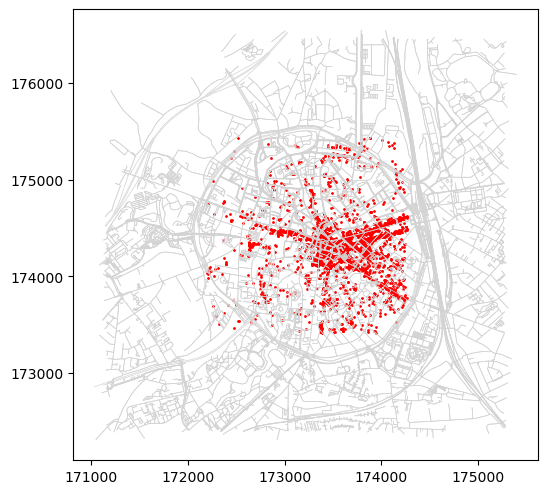

In [12]:
# visualize the cropped network and POIs
fig, ax = plt.subplots(figsize=(6, 6))
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped_filtered_level_one.plot(ax=ax, color='red', markersize=1)
plt.show()

In [13]:
category_level_two = fsq_poi_gdf_cropped_filtered_level_one['cat2_name'].unique()
print(len(category_level_two))
category_level_two

81


array(['Restaurant', 'Drugstore', 'Bar', 'Dessert Shop',
       'Convenience Store', 'Night Market', 'Food and Beverage Retail',
       'Food Truck', 'Cafe, Coffee, and Tea House',
       'Furniture and Home Store', 'Arts and Crafts Store',
       'Computers and Electronics Retail', 'Discount Store',
       'Cosmetics Store', 'Baby Store', 'Fashion Retail',
       'Sporting Goods Retail', 'Boutique', 'Miscellaneous Store',
       'Distillery', 'Brewery', 'Automotive Retail', 'Print Store',
       'Toy Store', 'Pharmacy', 'Cafeteria', 'Breakfast Spot',
       'Snack Place', 'Smoke Shop', 'Music Store', 'Bakery',
       'Pop-Up Store', 'Gift Store', 'Office Supply Store',
       'Shopping Mall', 'Outlet Store', 'Hobby Store',
       'Leather Goods Store', 'Eyecare Store', 'Shopping Plaza',
       'Construction Supplies Store', 'Hardware Store', 'Bookstore',
       'Record Store', 'Flower Store', 'Market', 'Pet Supplies Store',
       'Betting Shop', 'Vape Store', 'Textiles Store',
      

# Customer Generation Scenarios

We implement two spatial distribution scenarios for generating `n` customers (50, 100, or 200) from POIs:

1. **Scenario A (Clustered / Hotspot)**: Customers cluster around `k` centers, simulating commercial districts
2. **Scenario B (Dispersed / Spatially Balanced)**: Customers spread evenly via stratified grid sampling

In [15]:


def generate_customers_clustered(
    poi_gdf: gpd.GeoDataFrame,
    n_customers: int = 100,
    n_clusters: int = 5,
    sigma: float = 300.0,
    alpha: float = 1.0,
    d_min: float = 50.0,
    use_kmedoids: bool = True,
    random_state: int = 42,
) -> gpd.GeoDataFrame:
    """
    Scenario A: Generate clustered customers (hotspot distribution).

    Parameters
    ----------
    poi_gdf : GeoDataFrame
        Source POI points (already filtered).
    n_customers : int
        Total number of customers to generate.
    n_clusters : int
        Number of cluster centers.
    sigma : float
        Cluster spread (meters). Smaller = tighter clusters.
    alpha : float
        Dirichlet concentration. Smaller = more unequal cluster sizes.
    d_min : float
        Minimum distance (meters) between any two customers.
    use_kmedoids : bool
        If True, use KMedoids (centers are actual POIs); else KMeans.
    random_state : int
        Random seed.

    Returns
    -------
    GeoDataFrame
        Selected customer locations with cluster labels.
    """
    rng = np.random.default_rng(random_state)
    coords = np.array([(p.x, p.y) for p in poi_gdf.geometry])

    # A1. Determine cluster centers
    if use_kmedoids:
        model = KMedoids(n_clusters=n_clusters, random_state=random_state, metric='euclidean')
    else:
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    labels = model.fit_predict(coords)
    centers = model.cluster_centers_

    # A2. Allocate customers per cluster via Dirichlet
    proportions = rng.dirichlet([alpha] * n_clusters)
    cluster_sizes = np.round(proportions * n_customers).astype(int)
    # Adjust to ensure sum == n_customers
    diff = n_customers - cluster_sizes.sum()
    for i in range(abs(diff)):
        idx = i % n_clusters
        cluster_sizes[idx] += 1 if diff > 0 else -1
    cluster_sizes = np.clip(cluster_sizes, 0, None)

    # A3. Sample customers from each cluster
    selected_indices = []
    for k in range(n_clusters):
        n_k = cluster_sizes[k]
        if n_k == 0:
            continue
        # Compute Gaussian weights centered at cluster k
        dists = np.linalg.norm(coords - centers[k], axis=1)
        weights = np.exp(-dists**2 / (2 * sigma**2))
        weights /= weights.sum()

        # Sample without replacement
        available = np.arange(len(coords))
        sampled = []
        attempts = 0
        max_attempts = n_k * 50
        while len(sampled) < n_k and attempts < max_attempts:
            attempts += 1
            # Resample weights for remaining
            mask = np.isin(available, selected_indices + sampled, invert=True)
            pool = available[mask]
            if len(pool) == 0:
                break
            w = weights[pool]
            w /= w.sum()
            choice = rng.choice(pool, p=w)
            # Check d_min constraint
            if len(sampled) > 0:
                sampled_coords = coords[sampled]
                if np.min(np.linalg.norm(sampled_coords - coords[choice], axis=1)) < d_min:
                    continue
            if len(selected_indices) > 0:
                sel_coords = coords[selected_indices]
                if np.min(np.linalg.norm(sel_coords - coords[choice], axis=1)) < d_min:
                    continue
            sampled.append(choice)
        selected_indices.extend(sampled)

    result = poi_gdf.iloc[selected_indices].copy()
    result['cluster'] = [labels[i] for i in selected_indices]
    result = result.reset_index(drop=True)
    return result

In [16]:
def generate_customers_dispersed(
    poi_gdf: gpd.GeoDataFrame,
    n_customers: int = 100,
    n_carriers: int = 1,
    grid_size: float = 400.0,
    d_min: float = 50.0,
    random_state: int = 42,
) -> gpd.GeoDataFrame:
    """
    Scenario B: Generate spatially balanced / dispersed customers via stratified grid sampling.
    
    When n_carriers > 1, customers are evenly distributed among carriers, and each carrier's
    customers are spatially dispersed across the study area.

    Parameters
    ----------
    poi_gdf : GeoDataFrame
        Source POI points (already filtered).
    n_customers : int
        Total number of customers to generate.
    n_carriers : int
        Number of carriers to distribute customers among. Each carrier will receive
        approximately n_customers / n_carriers customers with dispersed spatial distribution.
    grid_size : float
        Grid cell edge length (meters).
    d_min : float
        Minimum distance (meters) between any two customers.
    random_state : int
        Random seed.

    Returns
    -------
    GeoDataFrame
        Selected customer locations with grid cell ids and carrier assignments.
    """
    rng = np.random.default_rng(random_state)
    poi_gdf = poi_gdf.copy().reset_index(drop=True)
    coords = np.array([(p.x, p.y) for p in poi_gdf.geometry])

    # Build grid over POI extent
    xmin, ymin, xmax, ymax = poi_gdf.total_bounds
    x_edges = np.arange(xmin, xmax + grid_size, grid_size)
    y_edges = np.arange(ymin, ymax + grid_size, grid_size)

    # Assign each POI to a grid cell
    poi_gdf['_grid_x'] = np.digitize(coords[:, 0], x_edges) - 1
    poi_gdf['_grid_y'] = np.digitize(coords[:, 1], y_edges) - 1
    poi_gdf['_grid_id'] = poi_gdf['_grid_x'].astype(str) + '_' + poi_gdf['_grid_y'].astype(str)

    # Group POIs by grid cell (non-empty cells only)
    cell_groups = {}
    for grid_id, group in poi_gdf.groupby('_grid_id'):
        cell_groups[grid_id] = group.index.tolist()
    non_empty_cells = list(cell_groups.keys())

    # Calculate customers per carrier
    base_count = n_customers // n_carriers
    remainder = n_customers % n_carriers
    customers_per_carrier = [base_count + (1 if i < remainder else 0) for i in range(n_carriers)]

    all_selected_indices = []
    all_carrier_ids = []
    global_selected = set()  # Track all selected indices to avoid duplicates

    for carrier_id in range(n_carriers):
        n_for_carrier = customers_per_carrier[carrier_id]
        carrier_selected = []
        attempts = 0
        max_attempts = n_for_carrier * 100

        # Create a local copy of cell_groups excluding already selected
        local_cell_groups = {
            cell: [idx for idx in indices if idx not in global_selected]
            for cell, indices in cell_groups.items()
        }
        local_non_empty_cells = [cell for cell, indices in local_cell_groups.items() if len(indices) > 0]

        while len(carrier_selected) < n_for_carrier and attempts < max_attempts:
            attempts += 1
            if not local_non_empty_cells:
                break
            # Uniformly sample a non-empty cell
            cell = rng.choice(local_non_empty_cells)
            candidates = local_cell_groups[cell]
            # Remove already selected (both global and local)
            candidates = [c for c in candidates if c not in global_selected and c not in carrier_selected]
            if not candidates:
                # Remove this cell from local non-empty cells
                local_non_empty_cells = [c for c in local_non_empty_cells if c != cell]
                continue
            # Pick one POI from the cell
            choice = rng.choice(candidates)
            # Check d_min constraint against this carrier's selected customers
            if len(carrier_selected) > 0:
                sel_coords = coords[carrier_selected]
                if np.min(np.linalg.norm(sel_coords - coords[choice], axis=1)) < d_min:
                    continue
            carrier_selected.append(choice)
            # Update local cell groups
            local_cell_groups[cell] = [c for c in local_cell_groups[cell] if c != choice]
            if len(local_cell_groups[cell]) == 0:
                local_non_empty_cells = [c for c in local_non_empty_cells if c != cell]

        # Add to global tracking
        global_selected.update(carrier_selected)
        all_selected_indices.extend(carrier_selected)
        all_carrier_ids.extend([carrier_id] * len(carrier_selected))

    result = poi_gdf.loc[all_selected_indices].copy()
    result['grid_id'] = result['_grid_id']
    result['carrier_id'] = all_carrier_ids
    result = result.drop(columns=['_grid_x', '_grid_y', '_grid_id'])
    result = result.reset_index(drop=True)
    return result

## Test: Generate 100 Customers for Each Scenario

In [18]:
# Generate customers for Scenario A (Clustered)
customers_clustered = generate_customers_clustered(
    fsq_poi_gdf_cropped_filtered_level_one,
    n_customers=100,
    n_clusters=4,
    sigma=300,
    alpha=1.0,
    d_min=50,
    use_kmedoids=True,
    random_state=42,
)
print(f"Scenario A (Clustered): {len(customers_clustered)} customers generated")
customers_clustered.head()

Scenario A (Clustered): 100 customers generated


,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry,cluster
0,57528fdd498ee5a2f7a7d758,Biomarkt Leuven,50.881675,4.710989,Diestsestraat,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Retail,Food and Beverage Retail,Grocery Store,Organic Grocery,None,None,POINT (174174.330 174585.601),0
1,4b4c5a0bf964a5205eb126e3,De Blauwe Schuit,50.882257,4.700116,Vismarkt 16,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Dining and Drinking,Restaurant,French Restaurant,Brasserie,None,None,POINT (173408.841 174646.953),3
2,4c33595a3896e21e0fdae990,Oesterbar,50.878008,4.702948,Muntstraat 23,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Dining and Drinking,Restaurant,Seafood Restaurant,None,None,None,POINT (173610.283 174175.137),2
3,59c5715b7918717eb3113099,Boter's palace,50.878161,4.704117,None,Leuven,None,None,None,None,...,None,None,Dining and Drinking,Bar,Cocktail Bar,None,None,None,POINT (173692.481 174192.530),2
4,4e18325452b123a586d40bbf,The Bake Off,50.881453,4.709805,Diestsestraat 152,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Dining and Drinking,Restaurant,Hot Dog Joint,None,None,None,POINT (174091.144 174560.525),0


In [19]:
# Generate customers for Scenario B (Dispersed)
customers_dispersed = generate_customers_dispersed(
    fsq_poi_gdf_cropped_filtered_level_one,
    n_customers=100,
    n_carriers=4,
    grid_size=400,
    d_min=50,
    random_state=42,
)
print(f"Scenario B (Dispersed): {len(customers_dispersed)} customers generated")
customers_dispersed.head()

Scenario B (Dispersed): 100 customers generated


,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry,grid_id,carrier_id
0,5812828e38fa608e85918ebc,Koyens Kommunistisches Kraakpand,50.881733,4.686504,Brusselsestraat 165,Leuven,None,3000,None,None,...,None,Dining and Drinking,Restaurant,Belgian Restaurant,None,None,None,POINT (172451.185 174584.420),0_2,0
1,616db2e33d590d0edbb7a344,Wolf Performance,50.887732,4.703071,Vaartkom 27,Leuven,None,3000,None,None,...,None,Retail,Sporting Goods Retail,Bicycle Store,None,None,None,POINT (173614.059 175256.962),3_4,0
2,669d49d73975e9236f5636a3,Crusco 7,50.881765,4.699147,Mechelsestraat 65A,Leuven,None,3000,None,None,...,None,Dining and Drinking,Restaurant,Belgian Restaurant,None,None,None,POINT (173340.901 174591.884),2_2,0
3,4b7689c5f964a52003512ee3,Veeakker,50.874074,4.689880,Slachthuislaan 3,Leuven,Vlaams-Brabant,3000,None,None,...,None,Retail,Food and Beverage Retail,Butcher,None,None,None,POINT (172692.429 173733.400),1_0,0
4,585713a40bc55b58b7263edf,TOPkot,50.873344,4.705588,None,Leuven,None,3000,None,None,...,None,Dining and Drinking,Bar,Sports Bar,None,None,None,POINT (173798.452 173657.140),3_0,0


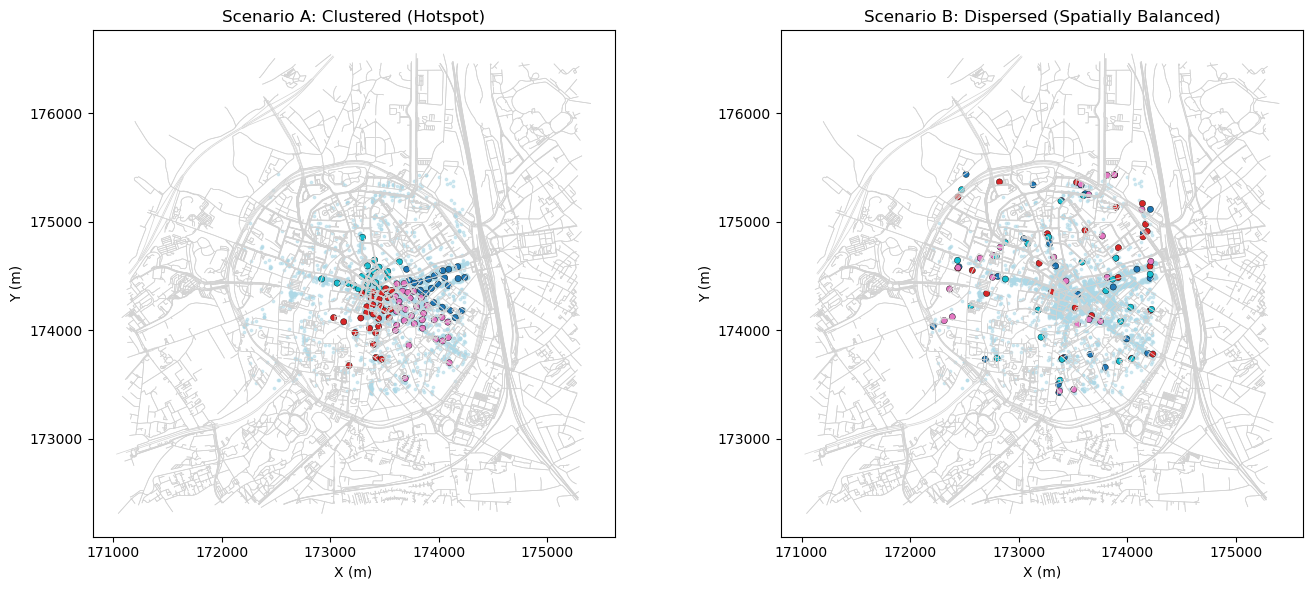

In [23]:
# Visualize both scenarios side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scenario A: Clustered
ax = axes[0]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped_filtered_level_one.plot(ax=ax, color='lightblue', markersize=3, alpha=0.5, label='All POIs')
customers_clustered.plot(ax=ax, column='cluster', cmap='tab10', markersize=20, legend=False, edgecolor='k', linewidth=0.3)
ax.set_title('Scenario A: Clustered (Hotspot)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# Scenario B: Dispersed
ax = axes[1]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped_filtered_level_one.plot(ax=ax, color='lightblue', markersize=3, alpha=0.5, label='All POIs')
customers_dispersed.plot(ax=ax, column='carrier_id', cmap='tab10', markersize=20, edgecolor='k', linewidth=0.3)
ax.set_title('Scenario B: Dispersed (Spatially Balanced)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

plt.tight_layout()
plt.show()

# Match locations to the network

In [24]:
def match_customers_to_links(
    customers_gdf: gpd.GeoDataFrame,
    network_gdf: gpd.GeoDataFrame,
    link_id_col: str = 'link_id',
) -> gpd.GeoDataFrame:
    """
    Match each customer to the nearest network link (edge).

    Parameters
    ----------
    customers_gdf : GeoDataFrame
        Customer point locations.
    network_gdf : GeoDataFrame
        Network links (LineString geometries).
    link_id_col : str
        Column name for link IDs in network_gdf.

    Returns
    -------
    GeoDataFrame
        Customers with added columns:
        - 'matched_link_id': ID of the nearest link
        - 'distance_to_link': distance (meters) to that link
        - 'snap_point': the closest point on the link geometry
    """
    from shapely.ops import nearest_points

    customers = customers_gdf.copy()
    
    # Prepare network links as a single unary union for fast nearest lookup
    # But we need per-link matching, so iterate
    link_geoms = network_gdf.geometry.values
    link_ids = network_gdf[link_id_col].values if link_id_col in network_gdf.columns else network_gdf.index.values

    matched_link_ids = []
    distances = []
    snap_points = []

    for pt in customers.geometry:
        min_dist = float('inf')
        best_link_id = None
        best_snap = None

        for link_id, link_geom in zip(link_ids, link_geoms):
            dist = pt.distance(link_geom)
            if dist < min_dist:
                min_dist = dist
                best_link_id = link_id
                # Get the closest point on the link
                _, snap_pt = nearest_points(pt, link_geom)
                best_snap = snap_pt

        matched_link_ids.append(best_link_id)
        distances.append(min_dist)
        snap_points.append(best_snap)

    customers['matched_link_id'] = matched_link_ids
    customers['distance_to_link'] = distances
    customers['snap_point'] = gpd.GeoSeries(snap_points, crs=customers.crs)

    return customers

In [26]:
def match_customers_to_links_fast(
    customers_gdf: gpd.GeoDataFrame,
    network_gdf: gpd.GeoDataFrame,
    link_id_col: str = 'link_id',
) -> gpd.GeoDataFrame:
    """
    Match each customer to the nearest network link (edge) using spatial index.
    
    Faster version using STRtree for large networks.

    Parameters
    ----------
    customers_gdf : GeoDataFrame
        Customer point locations.
    network_gdf : GeoDataFrame
        Network links (LineString geometries).
    link_id_col : str
        Column name for link IDs in network_gdf.

    Returns
    -------
    GeoDataFrame
        Customers with added columns:
        - 'matched_link_id': ID of the nearest link
        - 'distance_to_link': distance (meters) to that link
        - 'snap_point': the closest point on the link geometry
    """
    from shapely.strtree import STRtree
    from shapely.ops import nearest_points

    customers = customers_gdf.copy()
    network = network_gdf.copy().reset_index(drop=True)
    
    link_geoms = list(network.geometry.values)
    # Use link_id_col if present, otherwise fall back to index
    if link_id_col in network.columns:
        link_ids = network[link_id_col].values
    else:
        link_ids = network.index.values

    # Build spatial index
    tree = STRtree(link_geoms)

    matched_link_ids = []
    distances = []
    snap_points = []

    for pt in customers.geometry:
        # Query nearest geometry - returns index in Shapely >= 2.0
        nearest_idx = tree.nearest(pt)
        nearest_geom = link_geoms[nearest_idx]
        
        dist = pt.distance(nearest_geom)
        _, snap_pt = nearest_points(pt, nearest_geom)

        matched_link_ids.append(link_ids[nearest_idx])
        distances.append(dist)
        snap_points.append(snap_pt)

    customers['matched_link_id'] = matched_link_ids
    customers['distance_to_link'] = distances
    customers['snap_point'] = gpd.GeoSeries(snap_points, crs=customers.crs)

    return customers

## Match Customers to Network Links

In [27]:
# Match clustered customers to network links
customers_clustered_matched = match_customers_to_links_fast(
    customers_clustered,
    network_gdf_cropped4customer,
    link_id_col='link_id',
)
print(f"Matched {len(customers_clustered_matched)} clustered customers to links")
customers_clustered_matched[['cluster', 'matched_link_id', 'distance_to_link']].head(10)

Matched 100 clustered customers to links


,cluster,matched_link_id,distance_to_link
0,0,154334988_r_6,11.799252
1,3,306448632_r_6,3.001314
2,2,719918525_1,1.099130
3,2,527919914_58,13.181196
4,0,305434579_r_3,35.413751
5,0,578662093_0,3.224557
6,0,305434579_8,12.215630
7,1,362794322_r_19,18.740090
8,0,37769958_r_0,1.461072
9,2,528522834_r_0-528522834_r_1,2.538769


In [28]:
customers_clustered_matched

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry,cluster,matched_link_id,distance_to_link,snap_point
0,57528fdd498ee5a2f7a7d758,Biomarkt Leuven,50.881675,4.710989,Diestsestraat,Leuven,Vlaams-Brabant,3000,None,None,...,Food and Beverage Retail,Grocery Store,Organic Grocery,None,None,POINT (174174.330 174585.601),0,154334988_r_6,11.799252,POINT (174162.924 174582.581)
1,4b4c5a0bf964a5205eb126e3,De Blauwe Schuit,50.882257,4.700116,Vismarkt 16,Leuven,Vlaams-Brabant,3000,None,None,...,Restaurant,French Restaurant,Brasserie,None,None,POINT (173408.841 174646.953),3,306448632_r_6,3.001314,POINT (173411.783 174647.547)
2,4c33595a3896e21e0fdae990,Oesterbar,50.878008,4.702948,Muntstraat 23,Leuven,Vlaams-Brabant,3000,None,None,...,Restaurant,Seafood Restaurant,None,None,None,POINT (173610.283 174175.137),2,719918525_1,1.099130,POINT (173609.490 174174.376)
3,59c5715b7918717eb3113099,Boter's palace,50.878161,4.704117,None,Leuven,None,None,None,None,...,Bar,Cocktail Bar,None,None,None,POINT (173692.481 174192.530),2,527919914_58,13.181196,POINT (173680.783 174198.604)
4,4e18325452b123a586d40bbf,The Bake Off,50.881453,4.709805,Diestsestraat 152,Leuven,Vlaams-Brabant,3000,None,None,...,Restaurant,Hot Dog Joint,None,None,None,POINT (174091.144 174560.525),0,305434579_r_3,35.413751,POINT (174100.260 174526.305)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1fb28d62efd44823b08f0e7c,Fona Bvba,50.879702,4.699174,Brusselsestraat 19 Bus 6,Leuven,Vlaams-Brabant,3000,None,None,...,Fashion Retail,Clothing Store,None,None,None,POINT (173343.823 174362.391),3,293201772_r_0-293201772_r_1,7.346610,POINT (173337.447 174366.039)
96,4b195c70f964a520ecdb23e3,Onder Den Toren,50.884143,4.698536,Halfmaartstraat 2,Leuven,Vlaams-Brabant,3000,None,None,...,Restaurant,French Restaurant,None,None,None,POINT (173296.684 174856.280),3,816093128_0,19.574131,POINT (173314.966 174849.285)
97,4cd4502ca5b34688f9378750,Dijle Snack,50.881769,4.699179,Mechelsestraat,Leuven,Vlaams Gewest,3000,None,None,...,Restaurant,Pizzeria,None,None,None,POINT (173343.160 174592.377),3,305551912_1,15.582471,POINT (173329.463 174584.947)
98,5abd79eefc054d8476203a2e,June In The City,50.879500,4.701021,Raalbeeklaan 10,Leuven,Vlaams-Brabant,3001,None,None,...,Fashion Retail,Clothing Store,None,None,None,POINT (173473.913 174340.502),1,11364661_1,14.668936,POINT (173485.092 174350.000)


In [29]:
# Match dispersed customers to network links
customers_dispersed_matched = match_customers_to_links_fast(
    customers_dispersed,
    network_gdf_cropped4customer,
    link_id_col='link_id',
)
print(f"Matched {len(customers_dispersed_matched)} dispersed customers to links")
customers_dispersed_matched[['grid_id', 'matched_link_id', 'distance_to_link']].head(10)

Matched 100 dispersed customers to links


,grid_id,matched_link_id,distance_to_link
0,0_2,3752553_r_4,47.712358
1,3_4,splitLink_304242040_r_1_2,3.855301
2,2_2,305551912_1,13.377568
3,1_0,366337447_r_2-366337447_r_3-461159363_r_0-4611...,5.533695
4,3_0,48247088_r_3-893781380_0,17.458699
5,4_2,3991664_1-3991664_2,49.255373
6,4_1,13523027_7,6.388143
7,3_0,3990534_0,5.008840
8,4_5,15216997_r_2,3.931510
9,3_0,589477287_0,16.358080


In [31]:
customers_dispersed_matched

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat3_name,cat4_name,cat5_name,cat6_name,geometry,grid_id,carrier_id,matched_link_id,distance_to_link,snap_point
0,5812828e38fa608e85918ebc,Koyens Kommunistisches Kraakpand,50.881733,4.686504,Brusselsestraat 165,Leuven,None,3000,None,None,...,Belgian Restaurant,None,None,None,POINT (172451.185 174584.420),0_2,0,3752553_r_4,47.712358,POINT (172434.348 174539.777)
1,616db2e33d590d0edbb7a344,Wolf Performance,50.887732,4.703071,Vaartkom 27,Leuven,None,3000,None,None,...,Bicycle Store,None,None,None,POINT (173614.059 175256.962),3_4,0,splitLink_304242040_r_1_2,3.855301,POINT (173613.532 175253.143)
2,669d49d73975e9236f5636a3,Crusco 7,50.881765,4.699147,Mechelsestraat 65A,Leuven,None,3000,None,None,...,Belgian Restaurant,None,None,None,POINT (173340.901 174591.884),2_2,0,305551912_1,13.377568,POINT (173329.463 174584.947)
3,4b7689c5f964a52003512ee3,Veeakker,50.874074,4.689880,Slachthuislaan 3,Leuven,Vlaams-Brabant,3000,None,None,...,Butcher,None,None,None,POINT (172692.429 173733.400),1_0,0,366337447_r_2-366337447_r_3-461159363_r_0-4611...,5.533695,POINT (172691.886 173727.893)
4,585713a40bc55b58b7263edf,TOPkot,50.873344,4.705588,None,Leuven,None,3000,None,None,...,Sports Bar,None,None,None,POINT (173798.452 173657.140),3_0,0,48247088_r_3-893781380_0,17.458699,POINT (173782.054 173651.146)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4da58bb9fa8cf9bcc8805a35,Vivantia,50.883724,4.692579,Petermannenstraat 17,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,None,None,POINT (172877.735 174807.779),1_3,3,290143805_r_0-290143805_r_1-290143805_r_2,0.262728,POINT (172877.836 174808.022)
96,58b5ef2ddebdf6752c348ee1,Keuken BI12,50.877157,4.707644,None,Leuven,None,None,None,None,...,None,None,None,None,POINT (173941.226 174081.972),4_1,3,589420372_0-589420372_1-589420372_2-589420371_...,4.487608,POINT (173944.597 174079.010)
97,62923bd16c06bd0090d16062,Nepal Festival,50.883624,4.695537,None,Leuven,None,3000,None,None,...,None,None,None,None,POINT (173085.929 174797.552),2_3,3,290184425_r_3,2.345534,POINT (173087.851 174796.208)
98,58bdbd2f91936a61c9326abb,CT Keuken B5,50.882270,4.686317,Brusselsestraat 165,Leuven,None,3000,None,None,...,Belgian Restaurant,None,None,None,POINT (172437.768 174644.102),0_3,3,1085097726_1,40.129635,POINT (172449.936 174682.342)


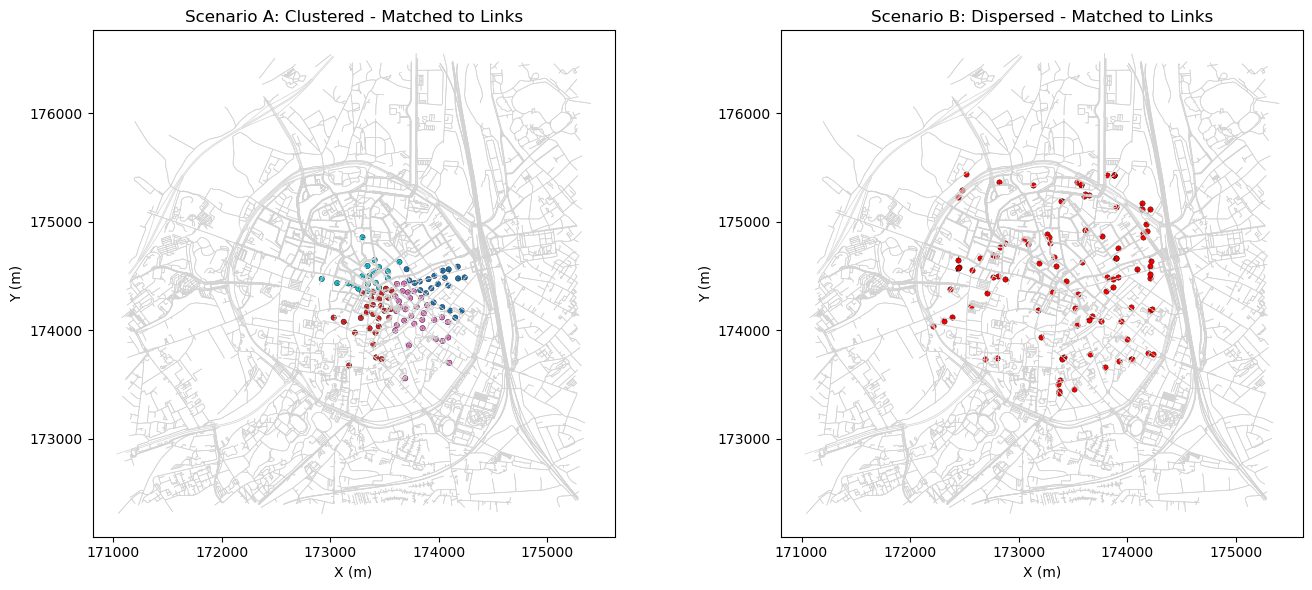

In [30]:
# Visualize matched customers with their snap points on the network
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scenario A: Clustered
ax = axes[0]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
customers_clustered_matched.plot(ax=ax, column='cluster', cmap='tab10', markersize=15, legend=False, edgecolor='k', linewidth=0.3, label='Customers')
# Draw lines from customer to snap point
for idx, row in customers_clustered_matched.iterrows():
    ax.plot([row.geometry.x, row.snap_point.x], [row.geometry.y, row.snap_point.y], 'k-', linewidth=0.5, alpha=0.5)
ax.set_title('Scenario A: Clustered - Matched to Links')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# Scenario B: Dispersed
ax = axes[1]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
customers_dispersed_matched.plot(ax=ax, color='red', markersize=15, edgecolor='k', linewidth=0.3, label='Customers')
# Draw lines from customer to snap point
for idx, row in customers_dispersed_matched.iterrows():
    ax.plot([row.geometry.x, row.snap_point.x], [row.geometry.y, row.snap_point.y], 'k-', linewidth=0.5, alpha=0.5)
ax.set_title('Scenario B: Dispersed - Matched to Links')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

plt.tight_layout()
plt.show()

In [37]:
''' Output the matched customers to csv file for further use (only need 'place_id, 'carrier_id/cluster', 'matched_link_id'') '''
demand_output_dir = r'data/randomDemand100Receivers'
customers_clustered_matched[['place_id', 'cluster', 'matched_link_id']].rename(columns={'cluster': 'carrier_id'}).to_csv(f'{demand_output_dir}/clustered/location_i01.csv.gz', index=False, compression='gzip')
customers_dispersed_matched[['place_id', 'carrier_id', 'matched_link_id']].to_csv(f'{demand_output_dir}/dispersed/location_i01.csv.gz', index=False, compression='gzip')

# Test

In [38]:
_ = pd.read_csv(f'{demand_output_dir}/dispersed/location_i01.csv.gz', compression='gzip')   
_

,place_id,carrier_id,matched_link_id
0,5812828e38fa608e85918ebc,0,3752553_r_4
1,616db2e33d590d0edbb7a344,0,splitLink_304242040_r_1_2
2,669d49d73975e9236f5636a3,0,305551912_1
3,4b7689c5f964a52003512ee3,0,366337447_r_2-366337447_r_3-461159363_r_0-4611...
4,585713a40bc55b58b7263edf,0,48247088_r_3-893781380_0
...,...,...,...
95,4da58bb9fa8cf9bcc8805a35,3,290143805_r_0-290143805_r_1-290143805_r_2
96,58b5ef2ddebdf6752c348ee1,3,589420372_0-589420372_1-589420372_2-589420371_...
97,62923bd16c06bd0090d16062,3,290184425_r_3
98,58bdbd2f91936a61c9326abb,3,1085097726_1
